In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

DATA_PATH = Path("../data/raw/Telco_customer_churn.csv")

df = pd.read_csv(DATA_PATH)

df.shape

(7043, 33)

In [4]:
drop_columns = [
    "CustomerID",
    "Count",
    "Churn Label",
    "Churn Score",
    "Churn Reason",
]

df = df.drop(columns=drop_columns)

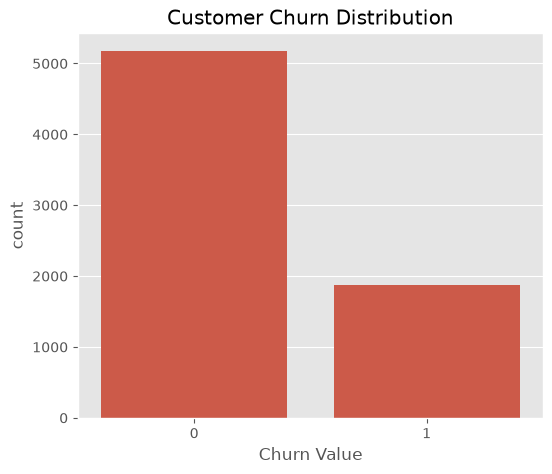

In [5]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Churn Value"
)

plt.title("Customer Churn Distribution")

plt.show()

## Business insight
Approximately one-quarter of customers churn. This indicates class imbalance, so metrics such as Precision, Recall, F1-score, and ROC-AUC will be more informative than accuracy alone.

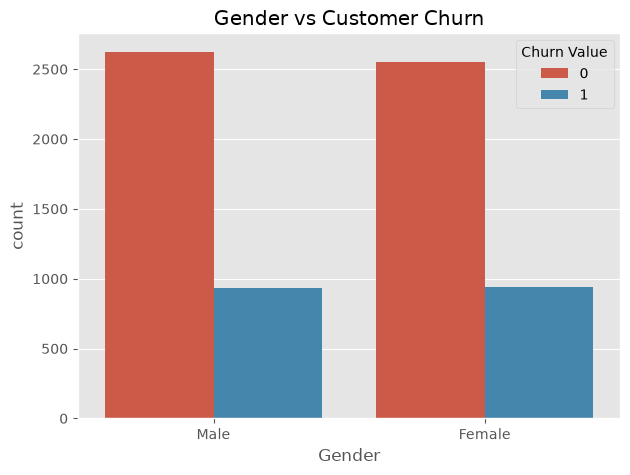

In [6]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Churn Value"
)

plt.title("Gender vs Customer Churn")

plt.show()

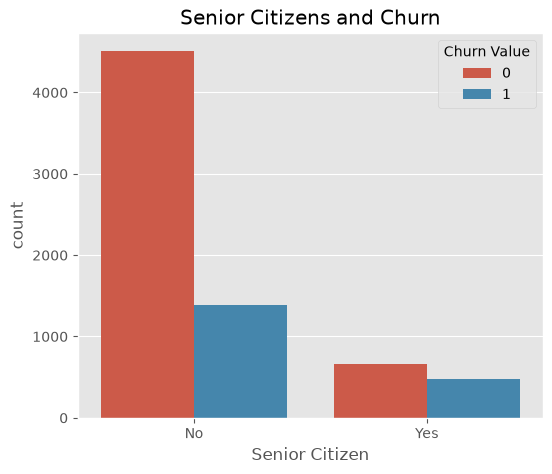

In [7]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Senior Citizen",
    hue="Churn Value"
)

plt.title("Senior Citizens and Churn")

plt.show()

## Business question:

Are senior citizens more likely to leave?

Yes

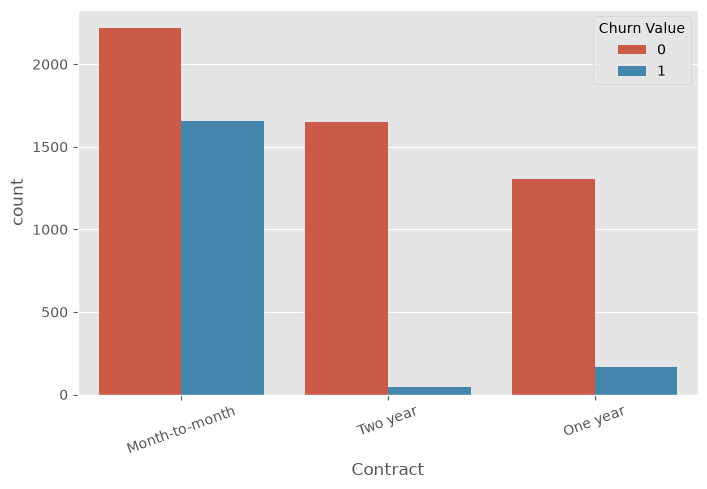

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn Value"
)

plt.xticks(rotation=20)
plt.savefig(
    "../images/churn_by_contract.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Business insight

Which contract has the highest churn?    M/M
Which has the lowest?                    two year
Why?                                     

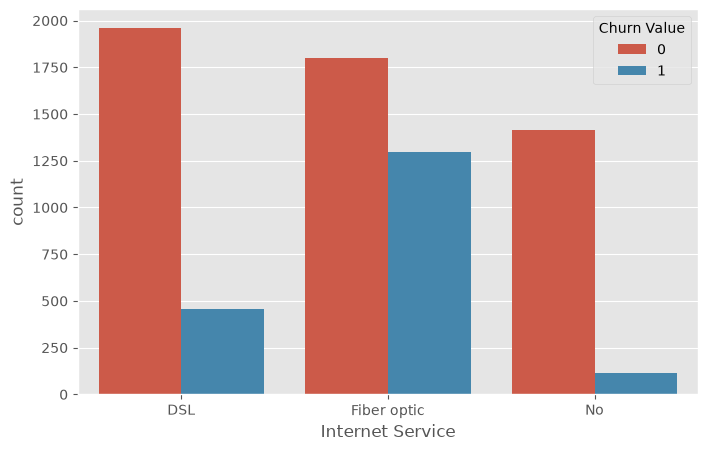

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Internet Service",
    hue="Churn Value"
)

plt.show()

## Business Insight
Which internet service has the highest churn?               Fiber Optic
Why might that happen?

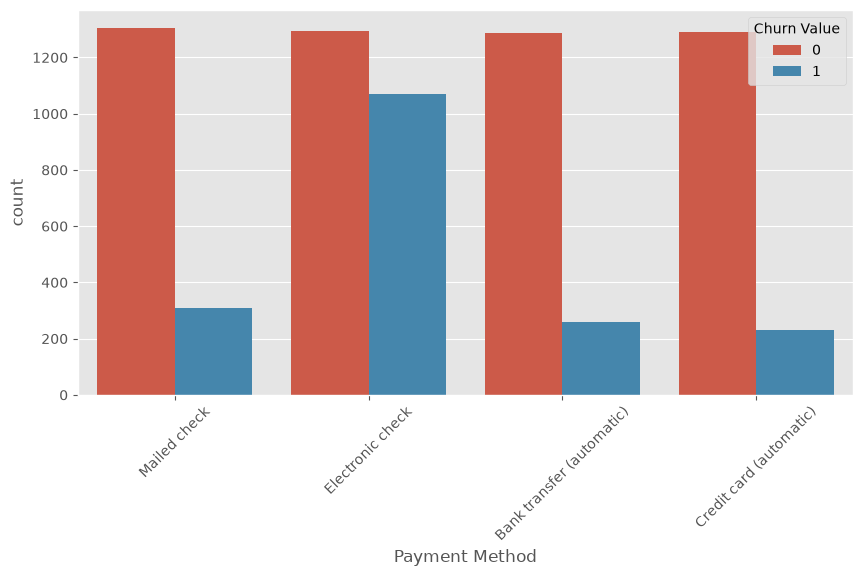

In [10]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Payment Method",
    hue="Churn Value"
)

plt.xticks(rotation=45)

plt.show()

## Business Insight

Does the payment method influence churn?       Yes 

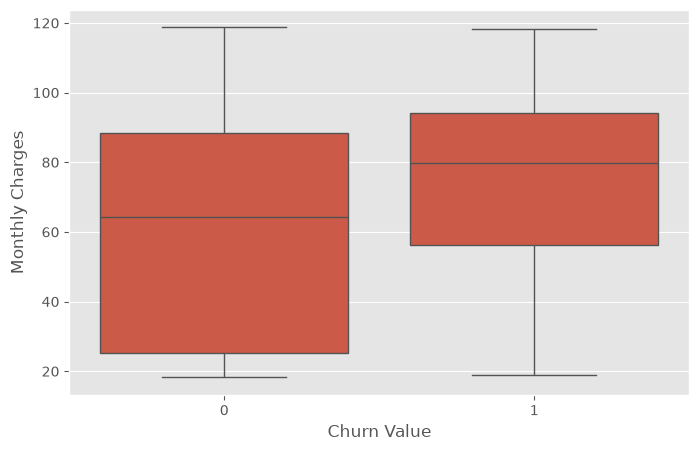

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    y="Churn Value",
    x="Monthly Charges"
)
plt.savefig(
    "../images/churn_by_monthly_charges.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

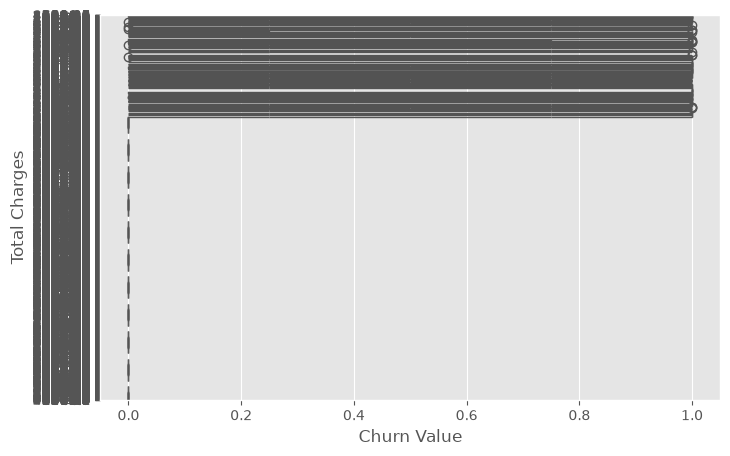

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Value",
    y="Total Charges"
)

plt.show()

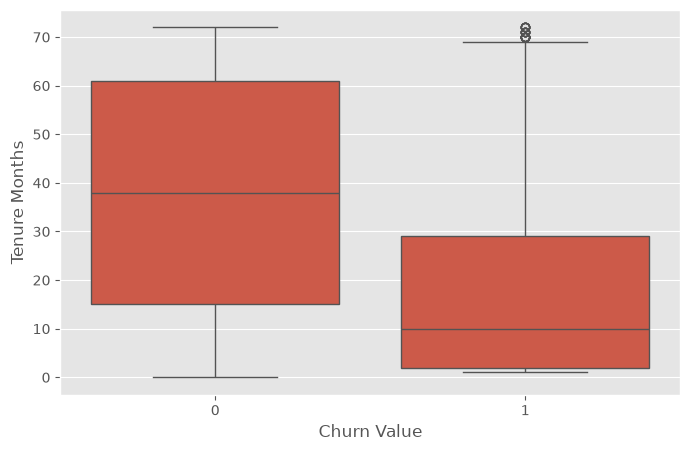

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Value",
    y="Tenure Months"
)
plt.savefig(
    "../images/churn_by_tenure.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

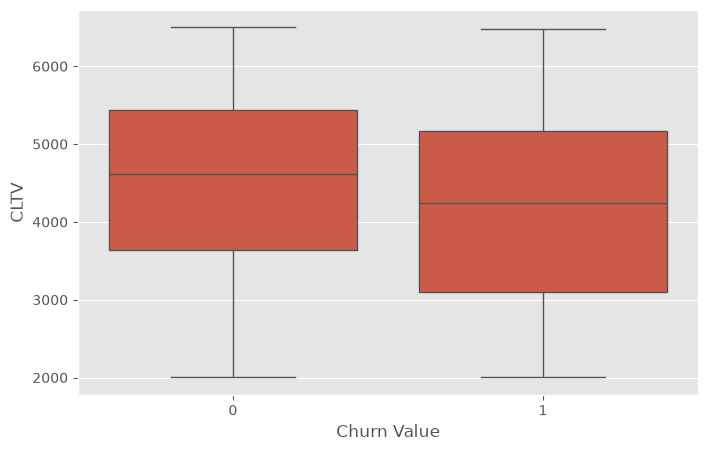

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Value",
    y="CLTV"
)

plt.show()

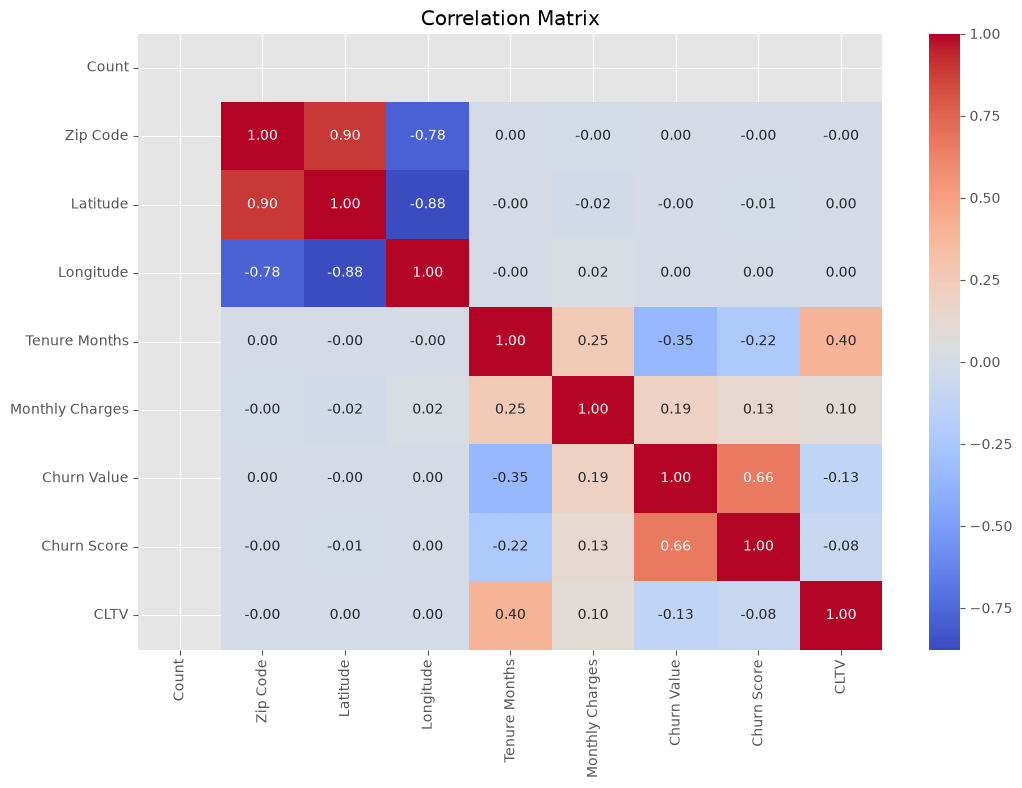

In [23]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.savefig(
    "../images/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

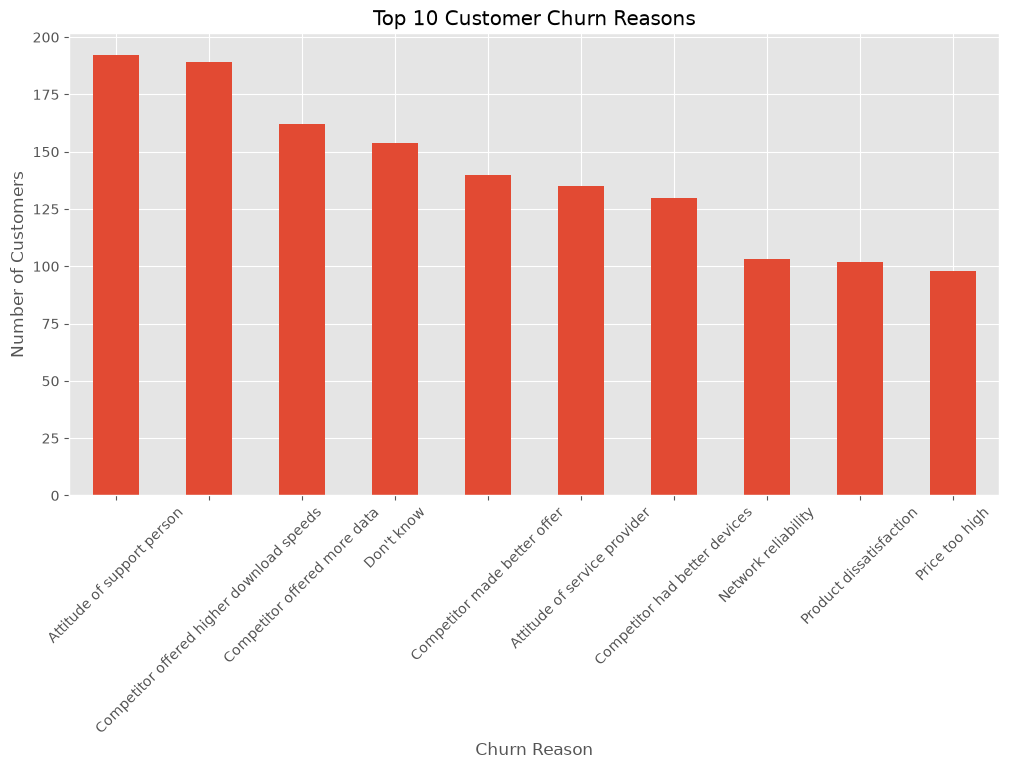

In [24]:
plt.figure(figsize=(12,6))

df["Churn Reason"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Customer Churn Reasons")

plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.savefig(
    "../images/churn_by_churn_reason.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

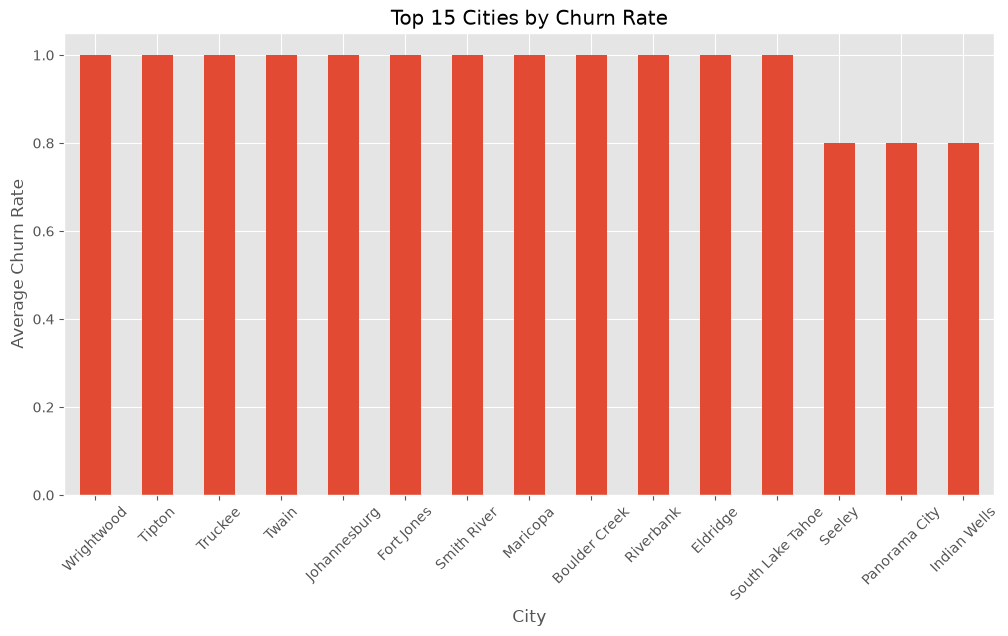

In [19]:
top_cities = (
    df.groupby("City")["Churn Value"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(12,6))

top_cities.plot(kind="bar")

plt.ylabel("Average Churn Rate")

plt.title("Top 15 Cities by Churn Rate")

plt.xticks(rotation=45)

plt.show()

## Key Findings

- Month-to-month customers have the highest churn.
- Customers with short tenure are more likely to leave.
- Higher monthly charges are associated with increased churn.
- Long-term contract customers show much lower churn.
- Certain payment methods have higher churn rates.
- CLTV differs between churned and retained customers.
- Churn reasons highlight opportunities to improve service quality and customer support.